## 1. Black & Scholes 

In [40]:
# On importe ce dont on a besoin ! 

import numpy as np 
from scipy.stats import norm
import matplotlib.pyplot as plt

In [41]:
S = 100 # spot price
K = 100 # strike price
T = 1 # time to maturity
r = 0.02 # rf 
sigma = 0.2 # volatility

In [42]:
def black_scholes(S, K ,T, r, sigma, option_type="call"):

    d1 = (np.log(S/K)+(r+0.5*sigma**2)*T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)

    if option_type == "call" : 
        price = S * norm.cdf(d1) - K * np.exp(-r*T)*norm.cdf(d2)
    else : 
        price = K * np.exp(-r*T) * norm.cdf(-d2) - S * norm.cdf(-d1)
    
    return price

call_price = black_scholes(S, K ,T, r, sigma, option_type="call")
put_price = black_scholes(S, K ,T, r, sigma, option_type="put")

print(f"Call price : {call_price}")
print(f"Put price : {put_price}")

Call price : 8.916037278572539
Put price : 6.93590460924807


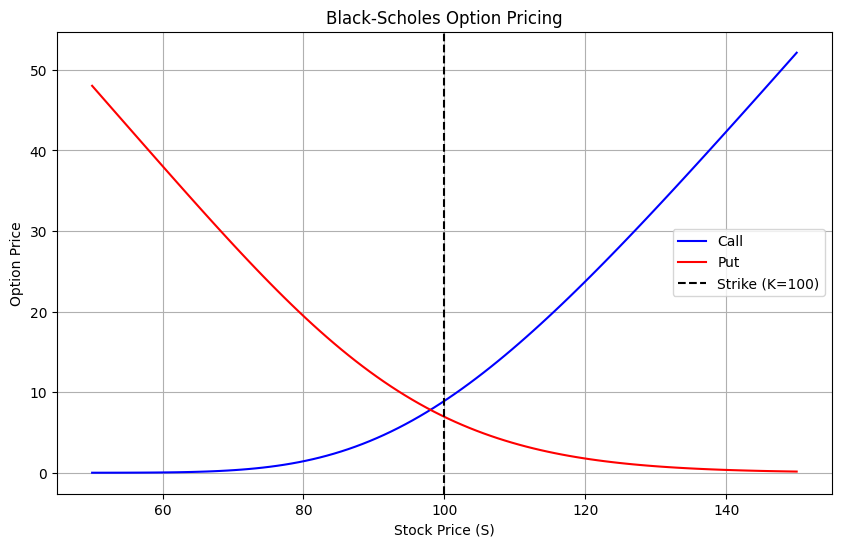

In [43]:
# visuel

# Les différents spot
spot_prices = np.linspace(50, 150, 100)

# On calcule les call et les put pour chaque spot 
call_prices = [black_scholes(s, K ,T, r, sigma, "call") for s in spot_prices]
put_prices = [black_scholes(s, K ,T, r, sigma, "put") for s in spot_prices]

# graph : 

plt.figure(figsize=(10, 6))
plt.plot(spot_prices, call_prices, label="Call", color="blue")
plt.plot(spot_prices, put_prices, label="Put", color="red")
plt.axvline(x=K, color="black", linestyle="--", label="Strike (K=100)")
plt.title("Black-Scholes Option Pricing")
plt.xlabel("Stock Price (S)")
plt.ylabel("Option Price")
plt.legend()
plt.grid(True)
plt.show()

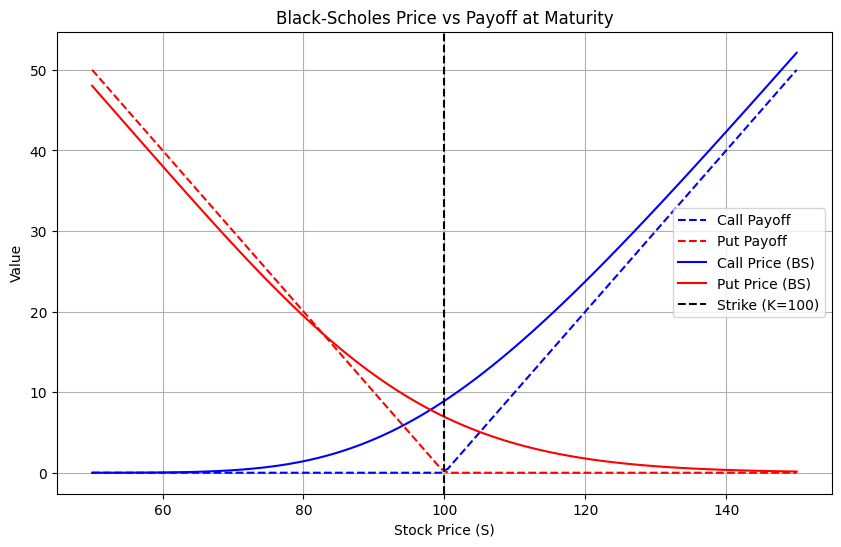

In [44]:
# Pour le payoff à maturié 

call_payoff = [max(s-K,0) for s in spot_prices]
put_payoff = [max(K-s,0) for s in spot_prices]

# graph 

plt.figure(figsize=(10, 6))
plt.plot(spot_prices, call_payoff, label="Call Payoff", color="blue", linestyle="--")
plt.plot(spot_prices, put_payoff, label="Put Payoff", color="red", linestyle="--")
plt.plot(spot_prices, call_prices, label="Call Price (BS)", color="blue")
plt.plot(spot_prices, put_prices, label="Put Price (BS)", color="red")
plt.axvline(x=K, color="black", linestyle="--", label="Strike (K=100)")
plt.title("Black-Scholes Price vs Payoff at Maturity")
plt.xlabel("Stock Price (S)")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()

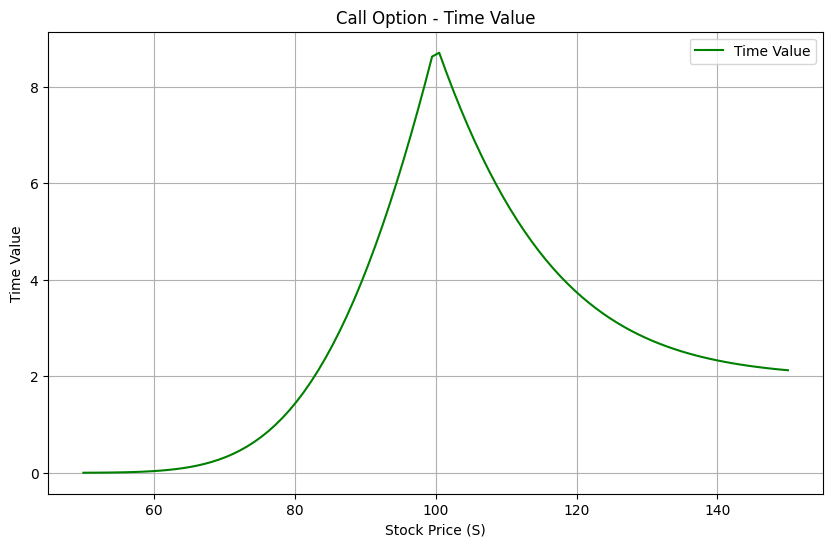

In [45]:
# calcule de la time value = prix de l'option - valeur intrinsèque 

call_intrinsic = [max(s-K,0) for s in spot_prices]
call_time_value = [c-i for c, i in zip(call_prices, call_intrinsic)]

plt.figure(figsize=(10, 6))
plt.plot(spot_prices, call_time_value, label="Time Value", color="green")
plt.title("Call Option - Time Value")
plt.xlabel("Stock Price (S)")
plt.ylabel("Time Value")
plt.legend()
plt.grid(True)
plt.show()

In [46]:
print("=" * 40)
print("     BLACK-SCHOLES PRICING SUMMARY")
print("=" * 40)
print(f"Stock Price (S)   : {S}")
print(f"Strike Price (K)  : {K}")
print(f"Maturity (T)      : {T} year")
print(f"Risk-free Rate (r): {r*100}%")
print(f"Volatility (σ)    : {sigma*100}%")
print("-" * 40)
print(f"Call Price        : {call_price:.2f}")
print(f"Put Price         : {put_price:.2f}")
print("=" * 40)

     BLACK-SCHOLES PRICING SUMMARY
Stock Price (S)   : 100
Strike Price (K)  : 100
Maturity (T)      : 1 year
Risk-free Rate (r): 2.0%
Volatility (σ)    : 20.0%
----------------------------------------
Call Price        : 8.92
Put Price         : 6.94


## 2. Monte Carlo Simulation

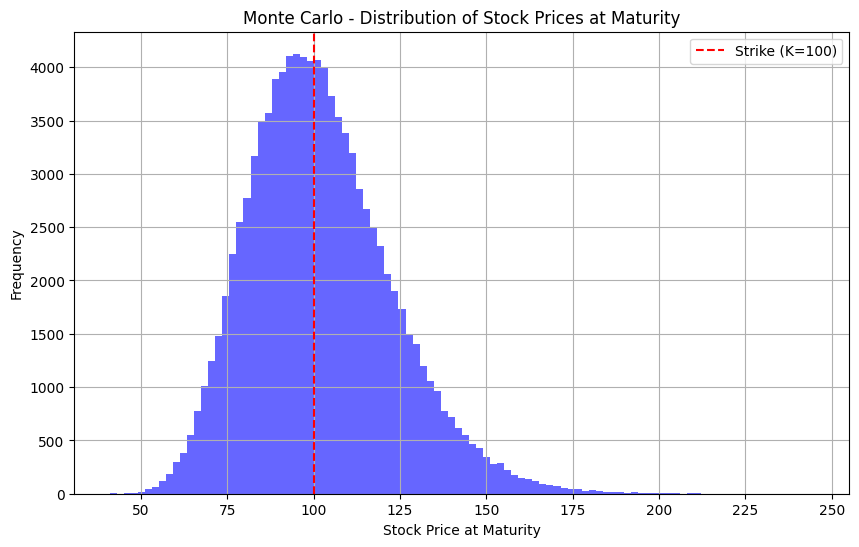

In [47]:
# Paramètres de la simulation de MC 

N = 100000
np.random.seed(42)

# Simulation des prix de l'action à maturité
Z = np.random.standard_normal(N)
ST = S * np.exp((r-0.5 * sigma**2) * T + sigma * np.sqrt(T)*Z)

# graph de la distribution des prix  
plt.figure(figsize=(10, 6))
plt.hist(ST, bins=100, color="blue", alpha=0.6)
plt.axvline(x=K, color="red", linestyle="--", label="Strike (K=100)")
plt.title("Monte Carlo - Distribution of Stock Prices at Maturity")
plt.xlabel("Stock Price at Maturity")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

In [48]:
# on calcule les payoffs des call et put 

call_payoff_mc = np.maximum(ST-K,0)
put_payoff_mc = np.maximum(K-ST, 0)


# on calcule le prix de l'option avec les payoffs

call_price_mc = np.exp(-r*T) * np.mean(call_payoff_mc)
put_price_mc = np.exp(-r*T) * np.mean(put_payoff_mc)


print("=" * 40)
print("    MONTE CARLO PRICING SUMMARY")
print("=" * 40)
print(f"Call Price (MC) : {call_price_mc:.2f}")
print(f"Put Price  (MC) : {put_price_mc:.2f}")
print("-" * 40)
print(f"Call Price (BS) : {call_price:.2f}")
print(f"Put Price  (BS) : {put_price:.2f}")
print("=" * 40)

    MONTE CARLO PRICING SUMMARY
Call Price (MC) : 8.94
Put Price  (MC) : 6.93
----------------------------------------
Call Price (BS) : 8.92
Put Price  (BS) : 6.94


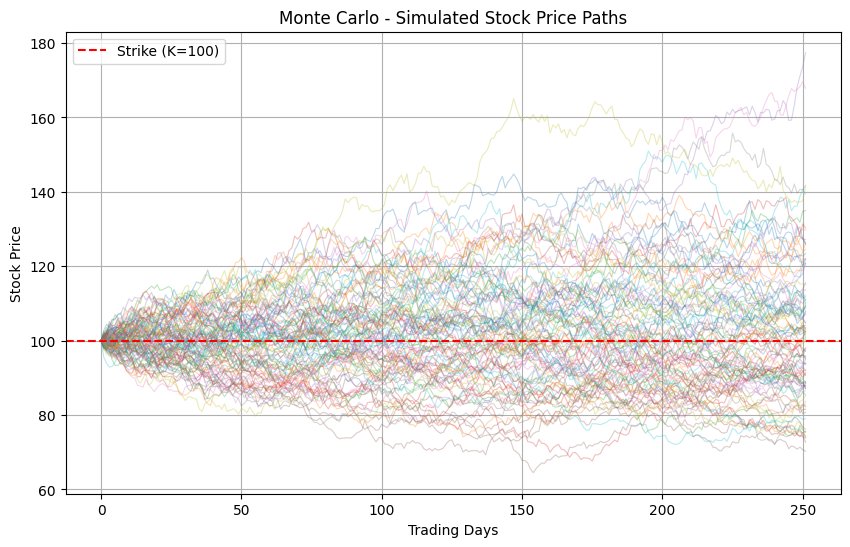

In [49]:
# on simule 100 trajectoires 

n_paths = 100
n_steps = 252 #nb de jours de trading 
dt = T / n_steps

paths = np.zeros((n_steps, n_paths))
paths[0] = S 

for t in range(1, n_steps) : 
    Z = np.random.standard_normal(n_paths)
    paths[t] = paths[t-1]* np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z)


# graph : 

plt.figure(figsize=(10, 6))
plt.plot(paths, alpha=0.3, linewidth=0.8)
plt.axhline(y=K, color="red", linestyle="--", label="Strike (K=100)")
plt.title("Monte Carlo - Simulated Stock Price Paths")
plt.xlabel("Trading Days")
plt.ylabel("Stock Price")
plt.legend()
plt.grid(True)
plt.show()

## 3. Binomial Tree (CRR)

In [52]:
# paramètres CRR 

N_steps = 100 # nombre de steps dans l'arbre
dt = T / N_steps # Time par step 

# Up et down facteurs 
u = np.exp(sigma * np.sqrt(dt))
d = 1 / u 

# proba risque neutre 
p = (np.exp(r*dt)-d) / (u-d)

print(f"Up factor   (u) : {u:.4f}")
print(f"Down factor (d) : {d:.4f}")
print(f"Probability (p) : {p:.4f}")

Up factor   (u) : 1.0202
Down factor (d) : 0.9802
Probability (p) : 0.5000


In [54]:
# on construit l'arbre 
stock_tree = np.zeros((N_steps + 1, N_steps +1))

for i in range(N_steps +1):
    for j in range(i+1):
        stock_tree[j, i] = S * (u**(i-j))*(d**j)


# on calcule le payoff de l'option à maturité 
option_tree = np.zeros((N_steps +1, N_steps +1))
option_tree[:, N_steps]= np.maximum(stock_tree[:, N_steps]-K,0) #call

# Backward induction
for i in range(N_steps - 1, -1, -1):
    for j in range(i + 1):
        option_tree[j, i] = np.exp(-r * dt) * (p * option_tree[j, i + 1] + (1 - p) * option_tree[j + 1, i + 1])

call_price_crr = option_tree[0, 0]

print("=" * 40)
print("      CRR PRICING SUMMARY")
print("=" * 40)
print(f"Call Price (CRR) : {call_price_crr:.2f}")
print(f"Call Price (MC)  : {call_price_mc:.2f}")
print(f"Call Price (BS)  : {call_price:.2f}")
print("=" * 40)

      CRR PRICING SUMMARY
Call Price (CRR) : 8.90
Call Price (MC)  : 8.94
Call Price (BS)  : 8.92


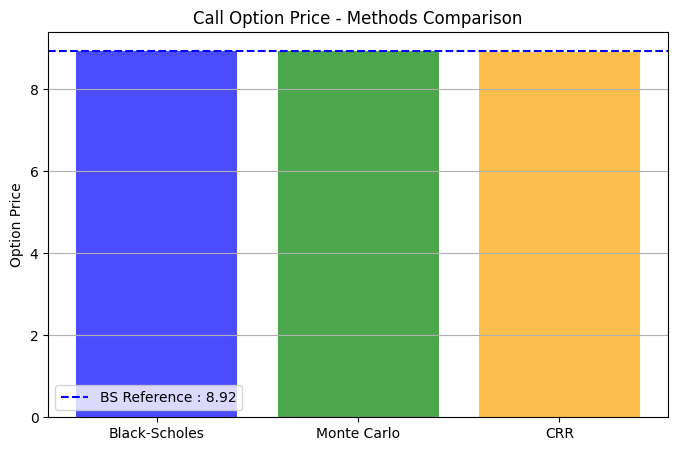

In [55]:
# Comparaison finale 

methods = ["Black-Scholes", "Monte Carlo", "CRR"]
prices = [call_price, call_price_mc, call_price_crr]

plt.figure(figsize=(8, 5))
plt.bar(methods, prices, color=["blue", "green", "orange"], alpha=0.7)
plt.axhline(y=call_price, color="blue", linestyle="--", label=f"BS Reference : {call_price:.2f}")
plt.title("Call Option Price - Methods Comparison")
plt.ylabel("Option Price")
plt.legend()
plt.grid(True, axis="y")
plt.show()
